In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    classification_report,
    multilabel_confusion_matrix
)

from model import TimeSeriesMultiLabelDataset, CNNBiLSTMMultiLabelClassifier

In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

OUTPUT_DIR = Path("mmi711_outputs_multilabel")
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
data = np.load(OUTPUT_DIR / "mmi711_multilabel_variable_length_datasets.npz")

with open(OUTPUT_DIR / "dataset_config_multilabel_variable_lengths.json", "r") as f:
    config = json.load(f)

LENGTHS = config["lengths"]
EVENT_LABELS = config["event_labels"]
EVENT_TO_ID = config["event_to_id"]
ID_TO_EVENT = {int(v): k for k, v in EVENT_TO_ID.items()}

meta_all = pd.read_csv(OUTPUT_DIR / "meta_all_multilabel_variable_lengths.csv")

print("Lengths:", LENGTHS)
print("Event labels:", EVENT_LABELS)
print("Metadata shape:", meta_all.shape)
print(meta_all[["dataset", "length", "scenario", "scenario_group", "background"]].head())

Lengths: [400, 800, 1200]
Event labels: ['mean_shift', 'variance_shift', 'trend_shift', 'point_anomaly', 'collective_anomaly']
Metadata shape: (7680, 11)
  dataset  length                        scenario scenario_group  \
0   train     400                  variance_shift   single_event   
1   train     400  trend_shift+collective_anomaly  shift_anomaly   
2   train     400                  variance_shift   single_event   
3   train     400                     trend_shift   single_event   
4   train     400              collective_anomaly   single_event   

           background  
0  single_seasonality  
1              linear  
2                none  
3              linear  
4  single_seasonality  


In [4]:
X_train_by_length = {}
Y_train_by_length = {}

X_val_by_length = {}
Y_val_by_length = {}

X_ood_params_by_length = {}
Y_ood_params_by_length = {}

X_ood_background_by_length = {}
Y_ood_background_by_length = {}

for length in LENGTHS:
    X_train_by_length[length] = data[f"X_train_L{length}"]
    Y_train_by_length[length] = data[f"Y_train_L{length}"]

    X_val_by_length[length] = data[f"X_val_L{length}"]
    Y_val_by_length[length] = data[f"Y_val_L{length}"]

    X_ood_params_by_length[length] = data[f"X_ood_params_L{length}"]
    Y_ood_params_by_length[length] = data[f"Y_ood_params_L{length}"]

    X_ood_background_by_length[length] = data[f"X_ood_background_L{length}"]
    Y_ood_background_by_length[length] = data[f"Y_ood_background_L{length}"]

    print(
        f"Length {length}:",
        "train", X_train_by_length[length].shape, Y_train_by_length[length].shape,
        "| val", X_val_by_length[length].shape, Y_val_by_length[length].shape,
        "| ood_params", X_ood_params_by_length[length].shape, Y_ood_params_by_length[length].shape,
        "| ood_background", X_ood_background_by_length[length].shape, Y_ood_background_by_length[length].shape
    )

Length 400: train (1600, 400) (1600, 5) | val (320, 400) (320, 5) | ood_params (320, 400) (320, 5) | ood_background (320, 400) (320, 5)
Length 800: train (1600, 800) (1600, 5) | val (320, 800) (320, 5) | ood_params (320, 800) (320, 5) | ood_background (320, 800) (320, 5)
Length 1200: train (1600, 1200) (1600, 5) | val (320, 1200) (320, 5) | ood_params (320, 1200) (320, 5) | ood_background (320, 1200) (320, 5)


In [5]:
def summarize_target_support(Y_by_length, split_name):
    Y_all = np.vstack([Y_by_length[length] for length in LENGTHS])
    
    print("\n" + "=" * 60)
    print(split_name)
    print("=" * 60)
    print("Total samples:", len(Y_all))
    print("No-event samples:", np.sum(Y_all.sum(axis=1) == 0))
    
    for i, label in enumerate(EVENT_LABELS):
        print(f"{label:22s}: {int(Y_all[:, i].sum())}")

summarize_target_support(Y_train_by_length, "Train")
summarize_target_support(Y_val_by_length, "Validation")
summarize_target_support(Y_ood_params_by_length, "OOD Params")
summarize_target_support(Y_ood_background_by_length, "OOD Background")


Train
Total samples: 4800
No-event samples: 300
mean_shift            : 1500
variance_shift        : 1500
trend_shift           : 1500
point_anomaly         : 1500
collective_anomaly    : 1500

Validation
Total samples: 960
No-event samples: 60
mean_shift            : 300
variance_shift        : 300
trend_shift           : 300
point_anomaly         : 300
collective_anomaly    : 300

OOD Params
Total samples: 960
No-event samples: 60
mean_shift            : 300
variance_shift        : 300
trend_shift           : 300
point_anomaly         : 300
collective_anomaly    : 300

OOD Background
Total samples: 960
No-event samples: 60
mean_shift            : 300
variance_shift        : 300
trend_shift           : 300
point_anomaly         : 300
collective_anomaly    : 300


In [6]:
BATCH_SIZE = 32

def create_loaders_by_length(X_by_length, Y_by_length, shuffle):
    loaders = []
    
    for length in LENGTHS:
        loader = DataLoader(
            TimeSeriesMultiLabelDataset(
                X_by_length[length],
                Y_by_length[length]
            ),
            batch_size=BATCH_SIZE,
            shuffle=shuffle
        )
        loaders.append(loader)
    
    return loaders

train_loaders = create_loaders_by_length(X_train_by_length, Y_train_by_length, shuffle=True)
val_loaders = create_loaders_by_length(X_val_by_length, Y_val_by_length, shuffle=False)
ood_params_loaders = create_loaders_by_length(X_ood_params_by_length, Y_ood_params_by_length, shuffle=False)
ood_background_loaders = create_loaders_by_length(X_ood_background_by_length, Y_ood_background_by_length, shuffle=False)

print("Number of train loaders:", len(train_loaders))

Number of train loaders: 3


In [7]:
model = CNNBiLSTMMultiLabelClassifier(
    num_labels=len(EVENT_LABELS),
    lstm_hidden=64,
    dropout=0.1
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",      # because we monitor validation macro F1
    factor=0.5,      # reduce LR by half
    patience=3,      # wait 3 epochs without improvement before reducing LR
    min_lr=1e-6
)

early_stopping_patience = 10
min_delta = 1e-4

print(model)

CNNBiLSTMMultiLabelClassifier(
  (cnn_branch): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (bilstm): LSTM(1, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=Fa

In [8]:
def compute_multilabel_metrics(y_true, y_pred):
    exact_match = accuracy_score(y_true, y_pred)

    macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    micro_precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
    micro_recall = recall_score(y_true, y_pred, average="micro", zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

    samples_f1 = f1_score(y_true, y_pred, average="samples", zero_division=0)

    h_loss = hamming_loss(y_true, y_pred)

    true_no_event = np.sum(y_true, axis=1) == 0
    pred_no_event = np.sum(y_pred, axis=1) == 0

    if np.sum(true_no_event) > 0:
        no_event_accuracy = np.mean(pred_no_event[true_no_event])
    else:
        no_event_accuracy = np.nan

    return {
        "exact_match_accuracy": exact_match,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,
        "samples_f1": samples_f1,
        "hamming_loss": h_loss,
        "no_event_accuracy": no_event_accuracy
    }


def apply_threshold(y_prob, threshold=0.5):
    threshold = np.asarray(threshold)

    if threshold.ndim == 0:
        return (y_prob >= threshold).astype(int)

    return (y_prob >= threshold.reshape(1, -1)).astype(int)

In [9]:
def run_one_epoch_multiple_lengths(model, loaders, optimizer=None, threshold=0.5):
    is_train = optimizer is not None

    if is_train:
        model.train()
        loaders = loaders.copy()
        random.shuffle(loaders)
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    all_probs = []
    all_targets = []

    for loader in loaders:
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            if is_train:
                optimizer.zero_grad()

            with torch.set_grad_enabled(is_train):
                logits = model(X_batch)
                loss = criterion(logits, Y_batch)

                if is_train:
                    loss.backward()
                    optimizer.step()

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            probs = torch.sigmoid(logits)

            all_probs.append(probs.detach().cpu().numpy())
            all_targets.append(Y_batch.detach().cpu().numpy())

    y_prob = np.vstack(all_probs)
    y_true = np.vstack(all_targets).astype(int)
    y_pred = apply_threshold(y_prob, threshold)

    avg_loss = total_loss / total_samples
    metrics = compute_multilabel_metrics(y_true, y_pred)

    return avg_loss, metrics

In [10]:
EPOCHS = 300
THRESHOLD = 0.5

history = []

best_val_f1 = -np.inf
epochs_without_improvement = 0

best_model_path = OUTPUT_DIR / "best_multilabel_cnn_bilstm_model.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss, train_metrics = run_one_epoch_multiple_lengths(
        model,
        train_loaders,
        optimizer=optimizer,
        threshold=THRESHOLD
    )

    val_loss, val_metrics = run_one_epoch_multiple_lengths(
        model,
        val_loaders,
        optimizer=None,
        threshold=THRESHOLD
    )

    val_macro_f1 = val_metrics["macro_f1"]

    # Scheduler step should be after validation metric is computed.
    scheduler.step(val_macro_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "learning_rate": current_lr
    }

    for key, value in train_metrics.items():
        row[f"train_{key}"] = value

    for key, value in val_metrics.items():
        row[f"val_{key}"] = value

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | Train Macro F1: {train_metrics['macro_f1']:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Macro F1: {val_macro_f1:.4f} | "
        f"Val Exact Match: {val_metrics['exact_match_accuracy']:.4f}"
    )

    if val_macro_f1 > best_val_f1 + min_delta:
        best_val_f1 = val_macro_f1
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "event_labels": EVENT_LABELS,
                "lengths": LENGTHS,
                "epoch": epoch,
                "best_val_macro_f1": best_val_f1,
                "threshold": THRESHOLD
            },
            best_model_path
        )

        print(f"New best model saved. Best validation macro F1: {best_val_f1:.4f}")

    else:
        epochs_without_improvement += 1
        print(
            f"No meaningful improvement for {epochs_without_improvement} epoch(s). "
            f"Best val macro F1: {best_val_f1:.4f}"
        )

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered at epoch {epoch}.")
        break


history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history_multilabel.csv", index=False)

print("Training finished.")
print("Best validation macro F1:", best_val_f1)
print("Best model saved to:", best_model_path)

Epoch 01 | LR: 0.001000 | Train Loss: 0.5792 | Train Macro F1: 0.2014 | Val Loss: 0.5532 | Val Macro F1: 0.2966 | Val Exact Match: 0.1354
New best model saved. Best validation macro F1: 0.2966
Epoch 02 | LR: 0.001000 | Train Loss: 0.5384 | Train Macro F1: 0.3115 | Val Loss: 0.5159 | Val Macro F1: 0.3650 | Val Exact Match: 0.1667
New best model saved. Best validation macro F1: 0.3650
Epoch 03 | LR: 0.001000 | Train Loss: 0.5155 | Train Macro F1: 0.4047 | Val Loss: 0.4964 | Val Macro F1: 0.4468 | Val Exact Match: 0.1979
New best model saved. Best validation macro F1: 0.4468
Epoch 04 | LR: 0.001000 | Train Loss: 0.4952 | Train Macro F1: 0.5071 | Val Loss: 0.4765 | Val Macro F1: 0.5148 | Val Exact Match: 0.2260
New best model saved. Best validation macro F1: 0.5148
Epoch 05 | LR: 0.001000 | Train Loss: 0.4720 | Train Macro F1: 0.5635 | Val Loss: 0.4503 | Val Macro F1: 0.6102 | Val Exact Match: 0.2823
New best model saved. Best validation macro F1: 0.6102
Epoch 06 | LR: 0.001000 | Train Los

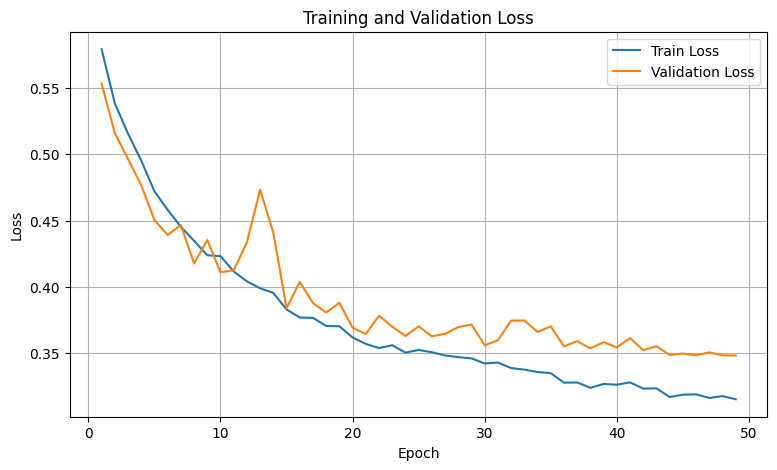

Saved: mmi711_outputs_multilabel\figures\multilabel_loss_curve.png


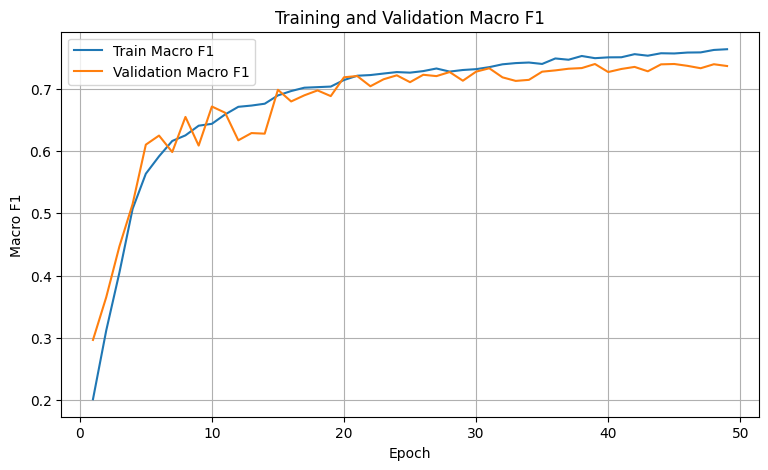

Saved: mmi711_outputs_multilabel\figures\multilabel_macro_f1_curve.png


In [11]:
plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

save_path = FIGURE_DIR / "multilabel_loss_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Training and Validation Macro F1")
plt.legend()
plt.grid(True)

save_path = FIGURE_DIR / "multilabel_macro_f1_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

In [12]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best validation macro F1:", checkpoint["best_val_macro_f1"])
print("Threshold:", checkpoint["threshold"])

Loaded best model from epoch: 39
Best validation macro F1: 0.7396755915222556
Threshold: 0.5


In [13]:
def get_predictions_multiple_lengths(model, loaders, threshold=0.5):
    model.eval()

    all_probs = []
    all_targets = []

    with torch.no_grad():
        for loader in loaders:
            for X_batch, Y_batch in loader:
                X_batch = X_batch.to(device)

                logits = model(X_batch)
                probs = torch.sigmoid(logits)

                all_probs.append(probs.cpu().numpy())
                all_targets.append(Y_batch.numpy())

    y_prob = np.vstack(all_probs)
    y_true = np.vstack(all_targets).astype(int)
    y_pred = apply_threshold(y_prob, threshold)

    return y_true, y_pred, y_prob


def get_eval_metadata(meta_all, dataset_name, lengths):
    frames = []

    for length in lengths:
        temp = meta_all[
            (meta_all["dataset"] == dataset_name) &
            (meta_all["length"] == length)
        ].copy()

        frames.append(temp)

    return pd.concat(frames, ignore_index=True)

In [14]:
def evaluate_multilabel_model(model, loaders, title, save_prefix, threshold=0.5):
    y_true, y_pred, y_prob = get_predictions_multiple_lengths(
        model,
        loaders,
        threshold=threshold
    )

    metrics = compute_multilabel_metrics(y_true, y_pred)

    print("\n" + title)
    print("=" * len(title))

    for key, value in metrics.items():
        print(f"{key:25s}: {value:.4f}")

    print("\nPer-label classification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=EVENT_LABELS,
        digits=4,
        zero_division=0
    ))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=EVENT_LABELS,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).T
    report_df.to_csv(OUTPUT_DIR / f"{save_prefix}_classification_report.csv")

    ml_cm = multilabel_confusion_matrix(y_true, y_pred)

    rows = []
    for i, label in enumerate(EVENT_LABELS):
        tn, fp, fn, tp = ml_cm[i].ravel()
        rows.append({
            "label": label,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    cm_df = pd.DataFrame(rows)
    cm_df.to_csv(OUTPUT_DIR / f"{save_prefix}_per_label_confusion_counts.csv", index=False)

    label_f1_scores = []
    for label in EVENT_LABELS:
        label_f1_scores.append(report_dict[label]["f1-score"])

    plt.figure(figsize=(9, 5))
    plt.bar(EVENT_LABELS, label_f1_scores)
    plt.ylim(0, 1)
    plt.ylabel("F1-score")
    plt.title(title + " - Per-label F1")
    plt.xticks(rotation=30)
    plt.grid(axis="y")

    save_path = FIGURE_DIR / f"{save_prefix}_per_label_f1.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved per-label F1 plot:", save_path)

    result_row = {
        "dataset": title
    }
    result_row.update(metrics)

    return result_row, y_true, y_pred, y_prob

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, multilabel_confusion_matrix

def compute_classwise_multilabel_metrics(
    y_true,
    y_pred,
    label_names,
    dataset_name,
    setting,
    thresholds
):
    rows = []

    ml_cm = multilabel_confusion_matrix(y_true, y_pred)

    thresholds = np.asarray(thresholds)

    for i, label in enumerate(label_names):
        tn, fp, fn, tp = ml_cm[i].ravel()

        if thresholds.ndim == 0:
            threshold_value = float(thresholds)
        else:
            threshold_value = float(thresholds[i])

        rows.append({
            "dataset": dataset_name,
            "setting": setting,
            "label": label,
            "threshold": threshold_value,
            "precision": precision_score(y_true[:, i], y_pred[:, i], zero_division=0),
            "recall": recall_score(y_true[:, i], y_pred[:, i], zero_division=0),
            "f1": f1_score(y_true[:, i], y_pred[:, i], zero_division=0),
            "support": int(y_true[:, i].sum()),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp)
        })

    return pd.DataFrame(rows)

In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score

def tune_multilabel_thresholds_per_class(
    y_true,
    y_prob,
    label_names,
    thresholds=None
):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    rows = []
    best_thresholds = []

    for class_idx, label in enumerate(label_names):
        best_threshold = 0.5
        best_f1 = -1
        best_precision = 0
        best_recall = 0

        for threshold in thresholds:
            y_pred_class = (y_prob[:, class_idx] >= threshold).astype(int)

            precision = precision_score(
                y_true[:, class_idx],
                y_pred_class,
                zero_division=0
            )

            recall = recall_score(
                y_true[:, class_idx],
                y_pred_class,
                zero_division=0
            )

            f1 = f1_score(
                y_true[:, class_idx],
                y_pred_class,
                zero_division=0
            )

            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
                best_precision = precision
                best_recall = recall

        best_thresholds.append(best_threshold)

        rows.append({
            "label": label,
            "best_threshold": best_threshold,
            "validation_precision": best_precision,
            "validation_recall": best_recall,
            "validation_f1": best_f1
        })

    threshold_df = pd.DataFrame(rows)

    return np.array(best_thresholds), threshold_df

In [17]:
y_true_val_for_tuning, y_pred_val_default, y_prob_val_for_tuning = get_predictions_multiple_lengths(
    model,
    val_loaders,
    threshold=0.5
)

TUNED_CLASS_THRESHOLDS, class_threshold_df = tune_multilabel_thresholds_per_class(
    y_true=y_true_val_for_tuning,
    y_prob=y_prob_val_for_tuning,
    label_names=EVENT_LABELS,
    thresholds=np.arange(0.05, 0.96, 0.01)
)

class_threshold_df.to_csv(
    OUTPUT_DIR / "validation_threshold_tuning_multilabel.csv",
    index=False
)

class_threshold_df

,label,best_threshold,validation_precision,validation_recall,validation_f1
0,mean_shift,0.46,0.785441,0.683333,0.730838
1,variance_shift,0.36,0.889796,0.726667,0.800000
2,trend_shift,0.32,0.602740,0.733333,0.661654
3,point_anomaly,0.46,0.723906,0.716667,0.720268
4,collective_anomaly,0.47,0.946939,0.773333,0.851376



Validation Set: In-Distribution
exact_match_accuracy     : 0.4271
macro_precision          : 0.8406
macro_recall             : 0.6633
macro_f1                 : 0.7397
micro_precision          : 0.8354
micro_recall             : 0.6633
micro_f1                 : 0.7395
samples_f1               : 0.6700
hamming_loss             : 0.1460
no_event_accuracy        : 0.4833

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.8255    0.6467    0.7252       300
    variance_shift     0.9663    0.6700    0.7913       300
       trend_shift     0.7232    0.5400    0.6183       300
     point_anomaly     0.7376    0.6933    0.7148       300
collective_anomaly     0.9504    0.7667    0.8487       300

         micro avg     0.8354    0.6633    0.7395      1500
         macro avg     0.8406    0.6633    0.7397      1500
      weighted avg     0.8406    0.6633    0.7397      1500
       samples avg     0.7644    0.6349    0.6700  

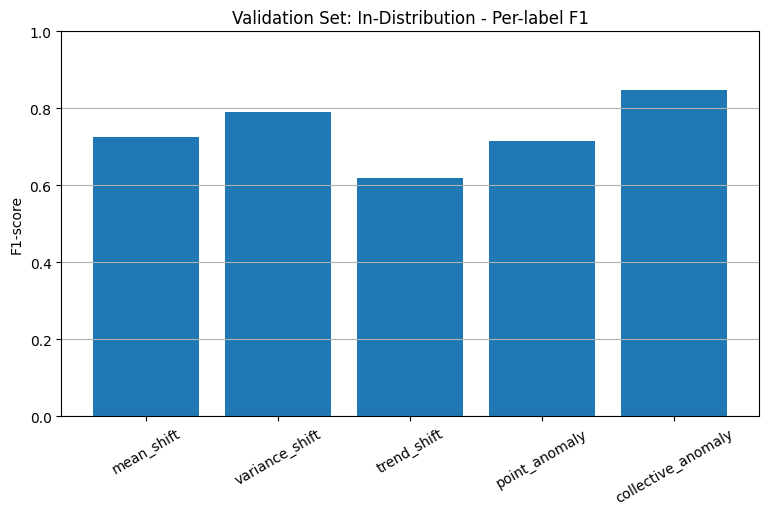

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\validation_default_per_label_f1.png

OOD Test A: Shifted Event Parameters
exact_match_accuracy     : 0.2760
macro_precision          : 0.7594
macro_recall             : 0.5000
macro_f1                 : 0.5885
micro_precision          : 0.7684
micro_recall             : 0.5000
micro_f1                 : 0.6058
samples_f1               : 0.5251
hamming_loss             : 0.2033
no_event_accuracy        : 0.6000

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.6617    0.4433    0.5309       300
    variance_shift     0.9204    0.3467    0.5036       300
       trend_shift     0.6615    0.4300    0.5212       300
     point_anomaly     0.5810    0.3467    0.4342       300
collective_anomaly     0.9722    0.9333    0.9524       300

         micro avg     0.7684    0.5000    0.6058      1500
         macro avg     0.7594    0.5000    0.5885      1500
      weigh

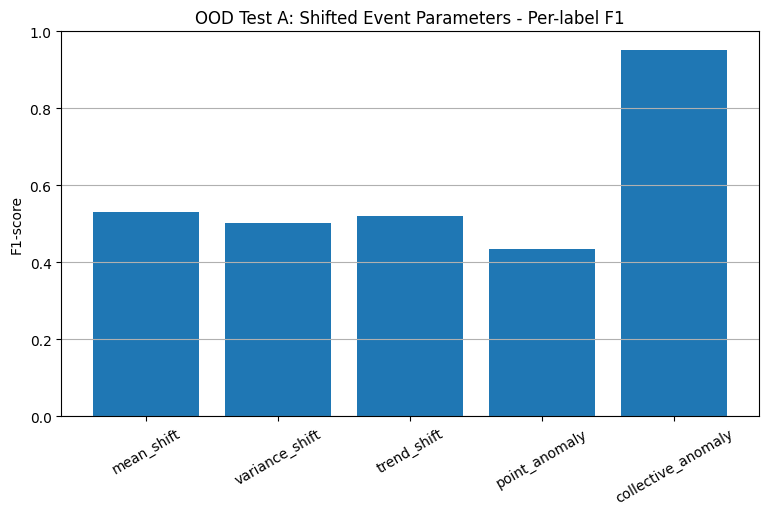

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\ood_params_default_per_label_f1.png

OOD Test B: Harder Backgrounds
exact_match_accuracy     : 0.2094
macro_precision          : 0.6176
macro_recall             : 0.5060
macro_f1                 : 0.5498
micro_precision          : 0.6226
micro_recall             : 0.5060
micro_f1                 : 0.5583
samples_f1               : 0.5009
hamming_loss             : 0.2502
no_event_accuracy        : 0.1833

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.5149    0.3467    0.4143       300
    variance_shift     0.5808    0.3233    0.4154       300
       trend_shift     0.4848    0.4800    0.4824       300
     point_anomaly     0.7068    0.7233    0.7150       300
collective_anomaly     0.8008    0.6567    0.7216       300

         micro avg     0.6226    0.5060    0.5583      1500
         macro avg     0.6176    0.5060    0.5498      1500
      weighted av

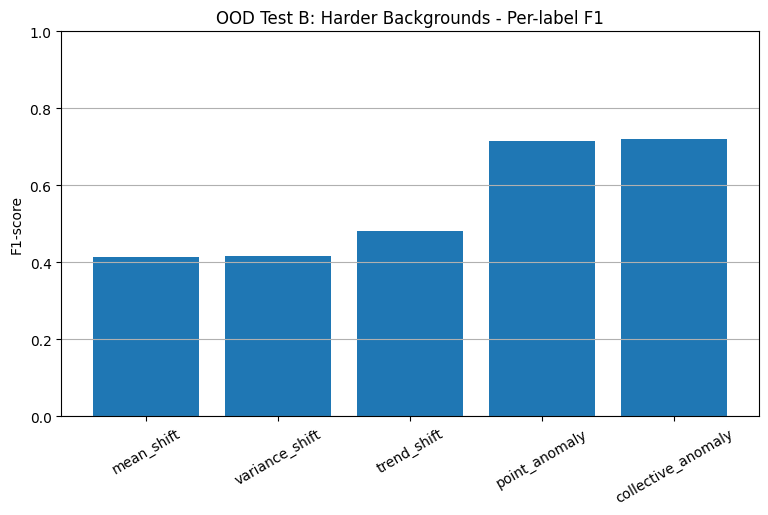

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\ood_background_default_per_label_f1.png


,dataset,exact_match_accuracy,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1,samples_f1,hamming_loss,no_event_accuracy
0,Validation Set: In-Distribution,0.427083,0.840619,0.663333,0.739676,0.835432,0.663333,0.739502,0.670000,0.146042,0.483333
1,OOD Test A: Shifted Event Parameters,0.276042,0.759362,0.500000,0.588480,0.768443,0.500000,0.605816,0.525104,0.203333,0.600000
2,OOD Test B: Harder Backgrounds,0.209375,0.617638,0.506000,0.549755,0.622642,0.506000,0.558293,0.500938,0.250208,0.183333


,dataset,setting,label,threshold,precision,recall,f1,support,tn,fp,fn,tp
0,validation,default_0.5,mean_shift,0.5,0.825532,0.646667,0.725234,300,619,41,106,194
1,validation,default_0.5,variance_shift,0.5,0.966346,0.670000,0.791339,300,653,7,99,201
2,validation,default_0.5,trend_shift,0.5,0.723214,0.540000,0.618321,300,598,62,138,162
3,validation,default_0.5,point_anomaly,0.5,0.737589,0.693333,0.714777,300,586,74,92,208
4,validation,default_0.5,collective_anomaly,0.5,0.950413,0.766667,0.848708,300,648,12,70,230
5,ood_params,default_0.5,mean_shift,0.5,0.661692,0.443333,0.530938,300,592,68,167,133
6,ood_params,default_0.5,variance_shift,0.5,0.920354,0.346667,0.503632,300,651,9,196,104
7,ood_params,default_0.5,trend_shift,0.5,0.661538,0.430000,0.521212,300,594,66,171,129
8,ood_params,default_0.5,point_anomaly,0.5,0.581006,0.346667,0.434238,300,585,75,196,104
9,ood_params,default_0.5,collective_anomaly,0.5,0.972222,0.933333,0.952381,300,652,8,20,280


In [18]:
results_default = []
classwise_default = []

val_result_default, y_true_val_default, y_pred_val_default, y_prob_val_default = evaluate_multilabel_model(
    model,
    val_loaders,
    "Validation Set: In-Distribution",
    "validation_default",
    threshold=0.5
)
results_default.append(val_result_default)

classwise_default.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_val_default,
        y_pred=y_pred_val_default,
        label_names=EVENT_LABELS,
        dataset_name="validation",
        setting="default_0.5",
        thresholds=0.5
    )
)

ood_params_result_default, y_true_ood_params_default, y_pred_ood_params_default, y_prob_ood_params_default = evaluate_multilabel_model(
    model,
    ood_params_loaders,
    "OOD Test A: Shifted Event Parameters",
    "ood_params_default",
    threshold=0.5
)
results_default.append(ood_params_result_default)

classwise_default.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_ood_params_default,
        y_pred=y_pred_ood_params_default,
        label_names=EVENT_LABELS,
        dataset_name="ood_params",
        setting="default_0.5",
        thresholds=0.5
    )
)

ood_background_result_default, y_true_ood_background_default, y_pred_ood_background_default, y_prob_ood_background_default = evaluate_multilabel_model(
    model,
    ood_background_loaders,
    "OOD Test B: Harder Backgrounds",
    "ood_background_default",
    threshold=0.5
)
results_default.append(ood_background_result_default)

classwise_default.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_ood_background_default,
        y_pred=y_pred_ood_background_default,
        label_names=EVENT_LABELS,
        dataset_name="ood_background",
        setting="default_0.5",
        thresholds=0.5
    )
)

results_df_default = pd.DataFrame(results_default)

results_df_default.to_csv(
    OUTPUT_DIR / "final_results_summary_multilabel_default_threshold.csv",
    index=False
)

classwise_df_default = pd.concat(classwise_default, ignore_index=True)

classwise_df_default.to_csv(
    OUTPUT_DIR / "classwise_results_multilabel_default_threshold.csv",
    index=False
)

display(results_df_default)
display(classwise_df_default)


Validation Set: In-Distribution
exact_match_accuracy     : 0.4302
macro_precision          : 0.7898
macro_recall             : 0.7267
macro_f1                 : 0.7528
micro_precision          : 0.7714
micro_recall             : 0.7267
micro_f1                 : 0.7484
samples_f1               : 0.6942
hamming_loss             : 0.1527
no_event_accuracy        : 0.3000

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.7854    0.6833    0.7308       300
    variance_shift     0.8898    0.7267    0.8000       300
       trend_shift     0.6027    0.7333    0.6617       300
     point_anomaly     0.7239    0.7167    0.7203       300
collective_anomaly     0.9469    0.7733    0.8514       300

         micro avg     0.7714    0.7267    0.7484      1500
         macro avg     0.7898    0.7267    0.7528      1500
      weighted avg     0.7898    0.7267    0.7528      1500
       samples avg     0.7519    0.6917    0.6942  

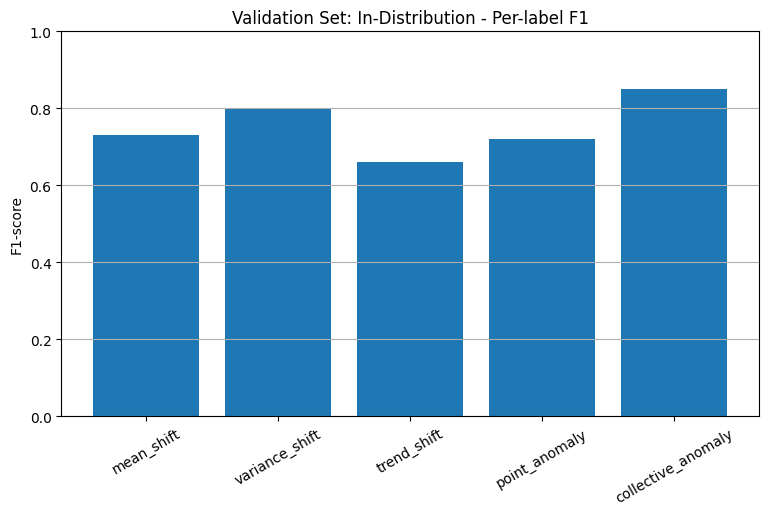

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\validation_tuned_per_label_f1.png

OOD Test A: Shifted Event Parameters
exact_match_accuracy     : 0.2750
macro_precision          : 0.6935
macro_recall             : 0.5727
macro_f1                 : 0.6147
micro_precision          : 0.6834
micro_recall             : 0.5727
micro_f1                 : 0.6231
samples_f1               : 0.5617
hamming_loss             : 0.2165
no_event_accuracy        : 0.3833

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.6278    0.4667    0.5354       300
    variance_shift     0.8000    0.4267    0.5565       300
       trend_shift     0.5186    0.6500    0.5769       300
     point_anomaly     0.5556    0.3833    0.4536       300
collective_anomaly     0.9656    0.9367    0.9509       300

         micro avg     0.6834    0.5727    0.6231      1500
         macro avg     0.6935    0.5727    0.6147      1500
      weighte

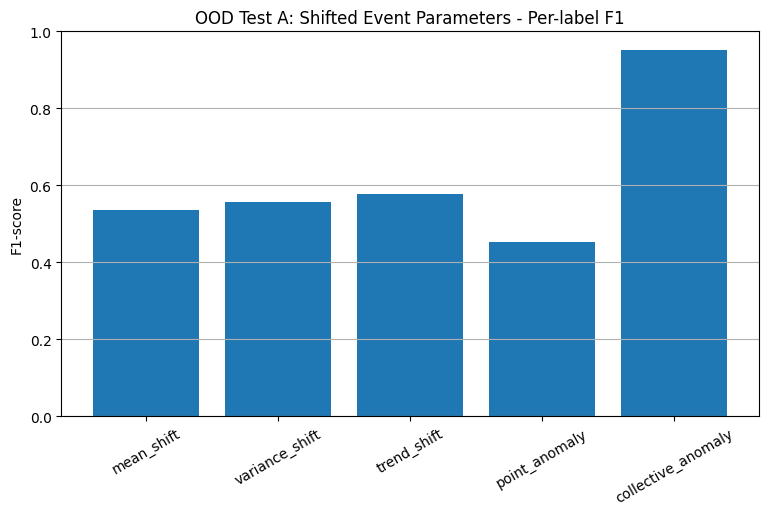

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\ood_params_tuned_per_label_f1.png

OOD Test B: Harder Backgrounds
exact_match_accuracy     : 0.1812
macro_precision          : 0.5759
macro_recall             : 0.5707
macro_f1                 : 0.5660
micro_precision          : 0.5624
micro_recall             : 0.5707
micro_f1                 : 0.5665
samples_f1               : 0.5214
hamming_loss             : 0.2729
no_event_accuracy        : 0.0667

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.4915    0.3833    0.4307       300
    variance_shift     0.4864    0.4167    0.4488       300
       trend_shift     0.4254    0.6467    0.5132       300
     point_anomaly     0.6962    0.7333    0.7143       300
collective_anomaly     0.7799    0.6733    0.7227       300

         micro avg     0.5624    0.5707    0.5665      1500
         macro avg     0.5759    0.5707    0.5660      1500
      weighted avg 

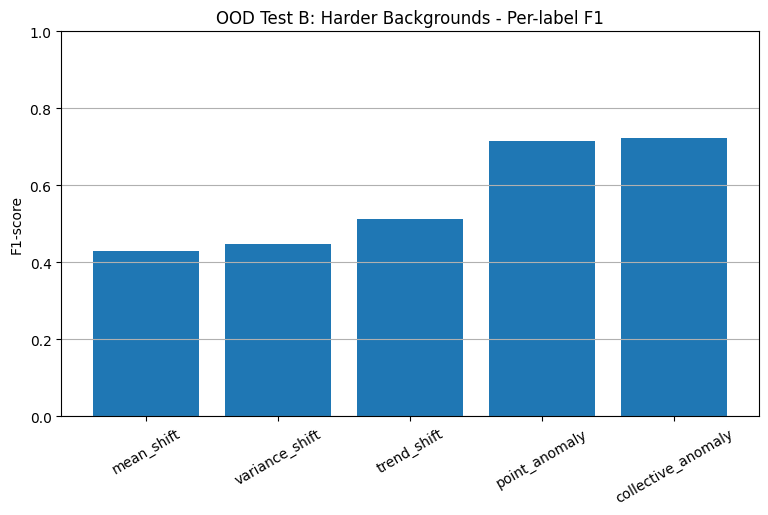

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\ood_background_tuned_per_label_f1.png


,dataset,exact_match_accuracy,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1,samples_f1,hamming_loss,no_event_accuracy
0,Validation Set: In-Distribution,0.430208,0.789764,0.726667,0.752827,0.771408,0.726667,0.748369,0.694201,0.152708,0.300000
1,OOD Test A: Shifted Event Parameters,0.275000,0.693522,0.572667,0.614679,0.683373,0.572667,0.623141,0.561667,0.216458,0.383333
2,OOD Test B: Harder Backgrounds,0.181250,0.575880,0.570667,0.565955,0.562418,0.570667,0.566512,0.521389,0.272917,0.066667


,dataset,setting,label,threshold,precision,recall,f1,support,tn,fp,fn,tp
0,validation,tuned,mean_shift,0.46,0.785441,0.683333,0.730838,300,604,56,95,205
1,validation,tuned,variance_shift,0.36,0.889796,0.726667,0.800000,300,633,27,82,218
2,validation,tuned,trend_shift,0.32,0.602740,0.733333,0.661654,300,515,145,80,220
3,validation,tuned,point_anomaly,0.46,0.723906,0.716667,0.720268,300,578,82,85,215
4,validation,tuned,collective_anomaly,0.47,0.946939,0.773333,0.851376,300,647,13,68,232
5,ood_params,tuned,mean_shift,0.46,0.627803,0.466667,0.535373,300,577,83,160,140
6,ood_params,tuned,variance_shift,0.36,0.800000,0.426667,0.556522,300,628,32,172,128
7,ood_params,tuned,trend_shift,0.32,0.518617,0.650000,0.576923,300,479,181,105,195
8,ood_params,tuned,point_anomaly,0.46,0.555556,0.383333,0.453649,300,568,92,185,115
9,ood_params,tuned,collective_anomaly,0.47,0.965636,0.936667,0.950931,300,650,10,19,281


In [19]:
results_tuned = []
classwise_tuned = []

val_result_tuned, y_true_val_tuned, y_pred_val_tuned, y_prob_val_tuned = evaluate_multilabel_model(
    model,
    val_loaders,
    "Validation Set: In-Distribution",
    "validation_tuned",
    threshold=TUNED_CLASS_THRESHOLDS
)
results_tuned.append(val_result_tuned)

classwise_tuned.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_val_tuned,
        y_pred=y_pred_val_tuned,
        label_names=EVENT_LABELS,
        dataset_name="validation",
        setting="tuned",
        thresholds=TUNED_CLASS_THRESHOLDS
    )
)

ood_params_result_tuned, y_true_ood_params_tuned, y_pred_ood_params_tuned, y_prob_ood_params_tuned = evaluate_multilabel_model(
    model,
    ood_params_loaders,
    "OOD Test A: Shifted Event Parameters",
    "ood_params_tuned",
    threshold=TUNED_CLASS_THRESHOLDS
)
results_tuned.append(ood_params_result_tuned)

classwise_tuned.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_ood_params_tuned,
        y_pred=y_pred_ood_params_tuned,
        label_names=EVENT_LABELS,
        dataset_name="ood_params",
        setting="tuned",
        thresholds=TUNED_CLASS_THRESHOLDS
    )
)

ood_background_result_tuned, y_true_ood_background_tuned, y_pred_ood_background_tuned, y_prob_ood_background_tuned = evaluate_multilabel_model(
    model,
    ood_background_loaders,
    "OOD Test B: Harder Backgrounds",
    "ood_background_tuned",
    threshold=TUNED_CLASS_THRESHOLDS
)
results_tuned.append(ood_background_result_tuned)

classwise_tuned.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_ood_background_tuned,
        y_pred=y_pred_ood_background_tuned,
        label_names=EVENT_LABELS,
        dataset_name="ood_background",
        setting="tuned",
        thresholds=TUNED_CLASS_THRESHOLDS
    )
)

results_df_tuned = pd.DataFrame(results_tuned)

results_df_tuned.to_csv(
    OUTPUT_DIR / "final_results_summary_multilabel_tuned_threshold.csv",
    index=False
)

classwise_df_tuned = pd.concat(classwise_tuned, ignore_index=True)

classwise_df_tuned.to_csv(
    OUTPUT_DIR / "classwise_results_multilabel_tuned_threshold.csv",
    index=False
)

display(results_df_tuned)
display(classwise_df_tuned)

In [20]:
# Add setting labels
results_default_compare = results_df_default.copy()
results_default_compare["setting"] = "default_0.5"

results_tuned_compare = results_df_tuned.copy()
results_tuned_compare["setting"] = "tuned"

# Combine default and tuned summary results
overall_threshold_comparison_long = pd.concat(
    [results_default_compare, results_tuned_compare],
    ignore_index=True
)

overall_threshold_comparison_long.to_csv(
    OUTPUT_DIR / "overall_default_vs_tuned_threshold_long.csv",
    index=False
)

overall_threshold_comparison_long

,dataset,exact_match_accuracy,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1,samples_f1,hamming_loss,no_event_accuracy,setting
0,Validation Set: In-Distribution,0.427083,0.840619,0.663333,0.739676,0.835432,0.663333,0.739502,0.670000,0.146042,0.483333,default_0.5
1,OOD Test A: Shifted Event Parameters,0.276042,0.759362,0.500000,0.588480,0.768443,0.500000,0.605816,0.525104,0.203333,0.600000,default_0.5
2,OOD Test B: Harder Backgrounds,0.209375,0.617638,0.506000,0.549755,0.622642,0.506000,0.558293,0.500938,0.250208,0.183333,default_0.5
3,Validation Set: In-Distribution,0.430208,0.789764,0.726667,0.752827,0.771408,0.726667,0.748369,0.694201,0.152708,0.300000,tuned
4,OOD Test A: Shifted Event Parameters,0.275000,0.693522,0.572667,0.614679,0.683373,0.572667,0.623141,0.561667,0.216458,0.383333,tuned
5,OOD Test B: Harder Backgrounds,0.181250,0.575880,0.570667,0.565955,0.562418,0.570667,0.566512,0.521389,0.272917,0.066667,tuned


In [21]:
# Merge default and tuned results side by side
overall_threshold_comparison_wide = results_df_default.merge(
    results_df_tuned,
    on="dataset",
    suffixes=("_default", "_tuned")
)

# Compute changes for numeric metric columns
for col in results_df_default.columns:
    if col == "dataset":
        continue

    if pd.api.types.is_numeric_dtype(results_df_default[col]):
        overall_threshold_comparison_wide[f"{col}_change"] = (
            overall_threshold_comparison_wide[f"{col}_tuned"] -
            overall_threshold_comparison_wide[f"{col}_default"]
        )

overall_threshold_comparison_wide.to_csv(
    OUTPUT_DIR / "overall_default_vs_tuned_threshold_comparison.csv",
    index=False
)

overall_threshold_comparison_wide

,dataset,exact_match_accuracy_default,macro_precision_default,macro_recall_default,macro_f1_default,micro_precision_default,micro_recall_default,micro_f1_default,samples_f1_default,hamming_loss_default,...,exact_match_accuracy_change,macro_precision_change,macro_recall_change,macro_f1_change,micro_precision_change,micro_recall_change,micro_f1_change,samples_f1_change,hamming_loss_change,no_event_accuracy_change
0,Validation Set: In-Distribution,0.427083,0.840619,0.663333,0.739676,0.835432,0.663333,0.739502,0.670000,0.146042,...,0.003125,-0.050855,0.063333,0.013152,-0.064024,0.063333,0.008867,0.024201,0.006667,-0.183333
1,OOD Test A: Shifted Event Parameters,0.276042,0.759362,0.500000,0.588480,0.768443,0.500000,0.605816,0.525104,0.203333,...,-0.001042,-0.065840,0.072667,0.026199,-0.085070,0.072667,0.017325,0.036563,0.013125,-0.216667
2,OOD Test B: Harder Backgrounds,0.209375,0.617638,0.506000,0.549755,0.622642,0.506000,0.558293,0.500938,0.250208,...,-0.028125,-0.041759,0.064667,0.016200,-0.060224,0.064667,0.008219,0.020451,0.022708,-0.116667


In [22]:
classwise_threshold_comparison_long = pd.concat(
    [classwise_df_default, classwise_df_tuned],
    ignore_index=True
)

classwise_threshold_comparison_long.to_csv(
    OUTPUT_DIR / "classwise_default_vs_tuned_threshold_long.csv",
    index=False
)

classwise_threshold_comparison_long

,dataset,setting,label,threshold,precision,recall,f1,support,tn,fp,fn,tp
0,validation,default_0.5,mean_shift,0.50,0.825532,0.646667,0.725234,300,619,41,106,194
1,validation,default_0.5,variance_shift,0.50,0.966346,0.670000,0.791339,300,653,7,99,201
2,validation,default_0.5,trend_shift,0.50,0.723214,0.540000,0.618321,300,598,62,138,162
3,validation,default_0.5,point_anomaly,0.50,0.737589,0.693333,0.714777,300,586,74,92,208
4,validation,default_0.5,collective_anomaly,0.50,0.950413,0.766667,0.848708,300,648,12,70,230
5,ood_params,default_0.5,mean_shift,0.50,0.661692,0.443333,0.530938,300,592,68,167,133
6,ood_params,default_0.5,variance_shift,0.50,0.920354,0.346667,0.503632,300,651,9,196,104
7,ood_params,default_0.5,trend_shift,0.50,0.661538,0.430000,0.521212,300,594,66,171,129
8,ood_params,default_0.5,point_anomaly,0.50,0.581006,0.346667,0.434238,300,585,75,196,104
9,ood_params,default_0.5,collective_anomaly,0.50,0.972222,0.933333,0.952381,300,652,8,20,280


In [23]:
classwise_threshold_comparison_wide = classwise_df_default.merge(
    classwise_df_tuned,
    on=["dataset", "label"],
    suffixes=("_default", "_tuned")
)

# Changes in main metrics
for metric in ["precision", "recall", "f1", "fp", "fn", "tp", "tn"]:
    classwise_threshold_comparison_wide[f"{metric}_change"] = (
        classwise_threshold_comparison_wide[f"{metric}_tuned"] -
        classwise_threshold_comparison_wide[f"{metric}_default"]
    )

classwise_threshold_comparison_wide.to_csv(
    OUTPUT_DIR / "classwise_default_vs_tuned_threshold_comparison.csv",
    index=False
)

classwise_threshold_comparison_wide

,dataset,setting_default,label,threshold_default,precision_default,recall_default,f1_default,support_default,tn_default,fp_default,...,fp_tuned,fn_tuned,tp_tuned,precision_change,recall_change,f1_change,fp_change,fn_change,tp_change,tn_change
0,validation,default_0.5,mean_shift,0.5,0.825532,0.646667,0.725234,300,619,41,...,56,95,205,-0.040091,0.036667,0.005604,15,-11,11,-15
1,validation,default_0.5,variance_shift,0.5,0.966346,0.670000,0.791339,300,653,7,...,27,82,218,-0.076550,0.056667,0.008661,20,-17,17,-20
2,validation,default_0.5,trend_shift,0.5,0.723214,0.540000,0.618321,300,598,62,...,145,80,220,-0.120475,0.193333,0.043334,83,-58,58,-83
3,validation,default_0.5,point_anomaly,0.5,0.737589,0.693333,0.714777,300,586,74,...,82,85,215,-0.013683,0.023333,0.005491,8,-7,7,-8
4,validation,default_0.5,collective_anomaly,0.5,0.950413,0.766667,0.848708,300,648,12,...,13,68,232,-0.003474,0.006667,0.002668,1,-2,2,-1
5,ood_params,default_0.5,mean_shift,0.5,0.661692,0.443333,0.530938,300,592,68,...,83,160,140,-0.033889,0.023333,0.004435,15,-7,7,-15
6,ood_params,default_0.5,variance_shift,0.5,0.920354,0.346667,0.503632,300,651,9,...,32,172,128,-0.120354,0.080000,0.052890,23,-24,24,-23
7,ood_params,default_0.5,trend_shift,0.5,0.661538,0.430000,0.521212,300,594,66,...,181,105,195,-0.142921,0.220000,0.055711,115,-66,66,-115
8,ood_params,default_0.5,point_anomaly,0.5,0.581006,0.346667,0.434238,300,585,75,...,92,185,115,-0.025450,0.036667,0.019411,17,-11,11,-17
9,ood_params,default_0.5,collective_anomaly,0.5,0.972222,0.933333,0.952381,300,652,8,...,10,19,281,-0.006586,0.003333,-0.001450,2,-1,1,-2


In [24]:
classwise_threshold_comparison_summary = classwise_threshold_comparison_wide[
    [
        "dataset",
        "label",

        "threshold_default",
        "threshold_tuned",

        "precision_default",
        "precision_tuned",

        "recall_default",
        "recall_tuned",

        "f1_default",
        "f1_tuned",

        "fp_default",
        "fp_tuned",

        "fn_default",
        "fn_tuned",
    ]
]

classwise_threshold_comparison_summary.to_csv(
    OUTPUT_DIR / "classwise_default_vs_tuned_threshold_summary.csv",
    index=False
)

classwise_threshold_comparison_summary

,dataset,label,threshold_default,threshold_tuned,precision_default,precision_tuned,recall_default,recall_tuned,f1_default,f1_tuned,fp_default,fp_tuned,fn_default,fn_tuned
0,validation,mean_shift,0.5,0.46,0.825532,0.785441,0.646667,0.683333,0.725234,0.730838,41,56,106,95
1,validation,variance_shift,0.5,0.36,0.966346,0.889796,0.670000,0.726667,0.791339,0.800000,7,27,99,82
2,validation,trend_shift,0.5,0.32,0.723214,0.602740,0.540000,0.733333,0.618321,0.661654,62,145,138,80
3,validation,point_anomaly,0.5,0.46,0.737589,0.723906,0.693333,0.716667,0.714777,0.720268,74,82,92,85
4,validation,collective_anomaly,0.5,0.47,0.950413,0.946939,0.766667,0.773333,0.848708,0.851376,12,13,70,68
5,ood_params,mean_shift,0.5,0.46,0.661692,0.627803,0.443333,0.466667,0.530938,0.535373,68,83,167,160
6,ood_params,variance_shift,0.5,0.36,0.920354,0.800000,0.346667,0.426667,0.503632,0.556522,9,32,196,172
7,ood_params,trend_shift,0.5,0.32,0.661538,0.518617,0.430000,0.650000,0.521212,0.576923,66,181,171,105
8,ood_params,point_anomaly,0.5,0.46,0.581006,0.555556,0.346667,0.383333,0.434238,0.453649,75,92,196,185
9,ood_params,collective_anomaly,0.5,0.47,0.972222,0.965636,0.933333,0.936667,0.952381,0.950931,8,10,20,19
